### imports:

In [65]:
# imports
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable


# F1)
Solve:

$$\frac{dy}{dt} = 1 + t - y, \quad y(0) = 1, \quad t \in [0, 1.2]$$

## F1.a)
Rita riktningsfältet för differentialekvationen (1) för t ∈ [0 T ]. Lägg sedan till den
exakta lösningen i samma i samma diagram så att du kan jämföra den med fältet. Den
exakta lösningen till ekvation (1) är y(t) = e−t + t.


We have the definition of the derivative from above, we plot the directional field by evaluating the derivative at a grid of points.

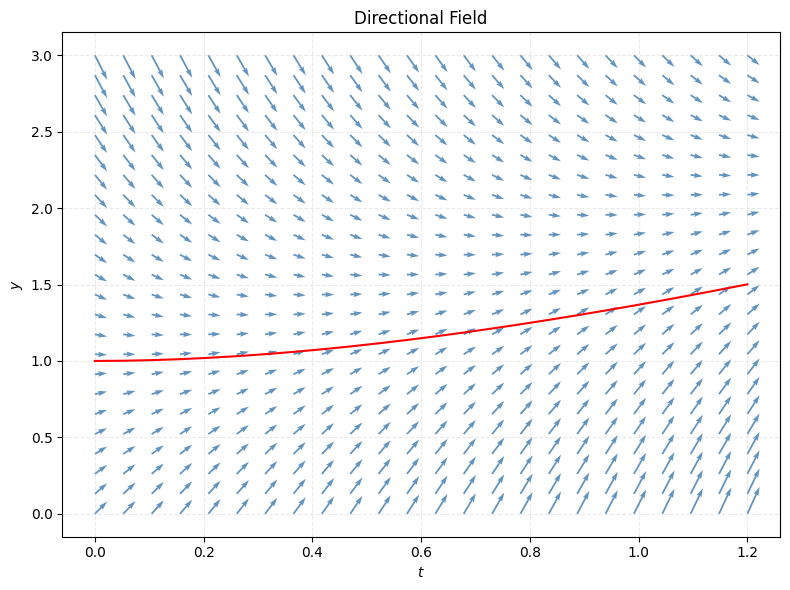

In [66]:
# directional field
t = np.linspace(0, 1.2, 24)
y = np.linspace(-0, 3, 24)
T, Y = np.meshgrid(t, y)
dY = 1 + T - Y
dT = np.ones_like(dY)

# Analytical solution
y_actual = np.exp(-t) + t


# uncomment this to normalize arrows in the plot but i think it resulted in a worse graph.
# L = np.sqrt(dT**2 + dY**2)
# dT = dT / L
# dY = dY / L


# Plot
plt.figure(figsize=(8, 6))
plt.quiver(T, Y, dT, dY, color="steelblue", alpha=0.85)
plt.plot(t, y_actual, color="red")
plt.xlabel(r"$t$")
plt.ylabel(r"$y$")
plt.title("Directional Field")
plt.grid(True, alpha=0.25, linestyle='dashed')
plt.tight_layout()
plt.show()


## F1.b)

Write a python program that solves DE1 using Euler forward $$DE_1: \quad y_{n+1} = y_n + h \cdot f(t_n, y_n), \quad h = 0.1$$ 

Create the euler forward function:

In [67]:
# forward_euler
@dataclass
class EulerResult:
    """
    Result container for Forward Euler method solutions.

    Fields
    ------
    t : np.ndarray
        Time points where solution is evaluated, shape (n_steps,)
    y : np.ndarray
        Numerical solution. Shape (n_steps,) for scalar ODEs or (n_vars, n_steps) for systems.
    e_i : np.ndarray
        Pointwise absolute error |y_exact(t) - y|. Same shape as y. Zeros if no exact solution provided.
    y_exact : np.ndarray | None
        Exact solution at time points t (if provided). Same shape as y. None otherwise.
    """

    t: np.ndarray
    y: np.ndarray
    e_i: np.ndarray
    y_exact: np.ndarray = None  # type: ignore


def euler_forward(
    f: Callable,
    y0: float | np.ndarray,  # float or np.ndarray
    domain: list,
    h: float,
    *f_args,  # Extra args for ODE, eg (R,L,C)
    exact: Callable = None,  # type: ignore
) -> EulerResult:
    """
    Solve ODE(s) y' = f(t,y) using Forward Euler method (universal: scalar or vector).

    Supports both scalar ODEs f(t,y)→float and systems f(t,y)→np.ndarray.

    Parameters
    ----------
    f : Callable
        ODE right-hand side:

            Scalar: f(t: float, y: float) → float

            Vector: f(t: float, y: np.ndarray, *f_args) → np.ndarray
    y0 : float | np.ndarray
        Initial condition. Scalar float or vector np.ndarray([q0, i0]).
    domain : list[float, float]
        Time interval [t_start, t_end]
    h : float
        Time step size
    *f_args
        Additional arguments passed to f() for vector ODEs (e.g., R, L, C for RLC)
    exact : Callable[[np.ndarray], np.ndarray | float], optional
        Exact solution y(t). Called as exact(t) where t is np.ndarray.

            Scalar: → np.ndarray (n_steps,)

            Vector: → np.ndarray (n_vars, n_steps)


    Returns
    -------
    EulerResult
        Container with t, y (numerical), e_i (errors), y_exact

    Notes
    -----
    - Automatically detects scalar vs vector ODE via np.isscalar(y0)
    - Forward Euler: y_{n+1} = y_n + h * f(t_n, y_n)
    - Order 1 accurate, conditionally stable
    """
    t = np.arange(domain[0], domain[1] + h, h)

    # Handle scalar vs vector automatically
    is_scalar: bool = np.isscalar(y0)
    n_vars: int = 1 if is_scalar else len(y0)  # type:ignore
    y: np.ndarray = np.zeros((len(t), n_vars))
    y[0] = y0 if is_scalar else y0.copy()  # type:ignore

    # Single step for scalar, vector step for systems
    for i in range(len(t) - 1):
        f_val = f(t[i], y[i], *f_args) if f_args else f(t[i], y[i])
        y[i + 1] = y[i] + h * f_val

    # Shape output
    if is_scalar:
        y = y[:, 0]  # 1D array for scalar case

    # Error
    if exact is not None:
        y_exact = exact(t)
        e_i = np.abs(y_exact - y)
    else:
        y_exact = None
        e_i = np.zeros_like(y)

    return EulerResult(t=t, y=y, e_i=e_i, y_exact=y_exact)  # type:ignore


## F1.b, c)

b) Skriv ett Python-program som approximerar lösningen till ekvation (1) med Eulers
metod-framåt och steglängden h = 0.1. Spara alla lösningsvärden (inklusive initialdata)
i en vektor och plotta den numeriska lösningsvektorn som funktion av tiden. Skriv din
kod så generellt som möjligt så att den går att återanvända för ett annat problem med
annat högerled f (t, y) och initialdata.

c) Verifiera att din lösning med Eulers metod-framåt vid tid t = T , ger felet ek = |yk (T ) −
yexakt (T )| ≈ 0.0188.

ANSWER B)


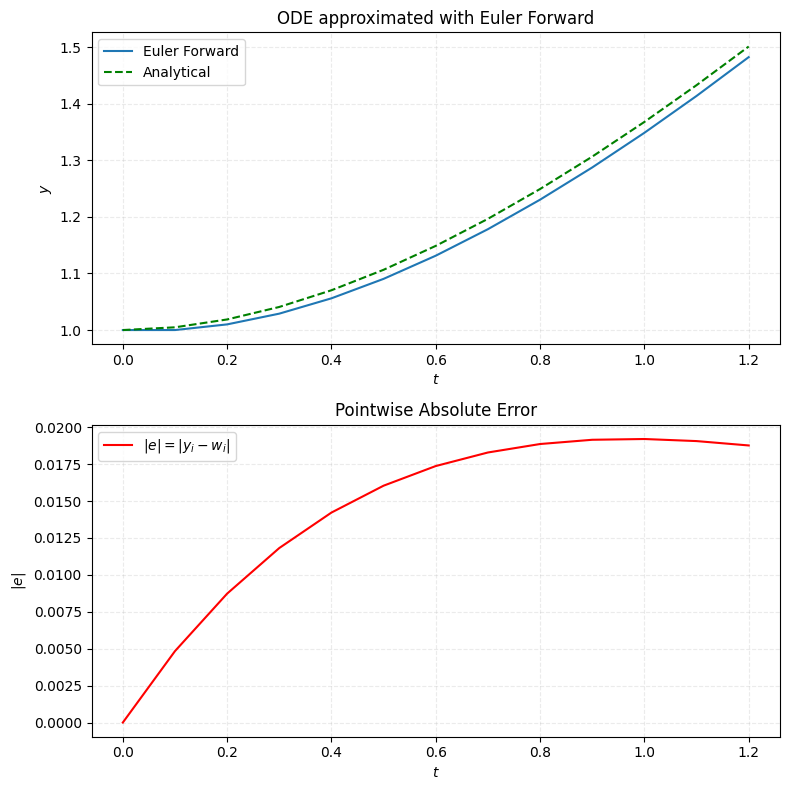

ANSWER C) Euler results error at t=T=1.2: 0.0188


In [68]:
# ODE approx with forward Euler
def ODE1(t: float, y: float) -> float:
    return 1 + t - y


def ODE1_actual(t):
    return np.exp(-t) + t


y0 = 1
domain = [0, 1.2]
h = 0.1

results: EulerResult = euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
print("ANSWER B)")
# Top plot: solution
ax1.plot(results.t, results.y, label="Euler Forward")
ax1.plot(
    results.t, results.y_exact, color="green", linestyle="dashed", label="Analytical"
)
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$y$")
ax1.set_title("ODE approximated with Euler Forward")
ax1.grid(True, alpha=0.25, linestyle='dashed')
ax1.legend()

# Bottom plot: error
ax2.plot(results.t, results.e_i, color="red", label=r"$|e| = |y_i - w_i|$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$|e|$")
ax2.set_title("Pointwise Absolute Error")
ax2.grid(True, alpha=0.25, linestyle='dashed')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"ANSWER C) Euler results error at t=T=1.2: {results.e_i[-1]:1.4f}")


___
# F2) konvergensstudie för problemet i F1

## F2.a, b)

a) Börja med h = 0.2 och halvera h successivt fyra gånger så att h = 0.2, 0.1, 0.05, 0.025, 0.0125.
För varje värde på h, beräkna en numerisk lösning med Euler framåt fram till sluttiden
T . För varje h, spara lösningen vid sluttiden T , yk (T ).

b) Beräkna felen i de numeriska lösningarna från a) enligt ek = |yk (T ) − yexakt (T )|.
Verifiera att felen blir [3.91 · 10−2 , 1.88 · 10−2 , 9.21 · 10−3 , 4.56 · 10−3 , 2.27 · 10−3 ] för
h = 0.2, 0.1, 0.05, 0.025, 0.0125.

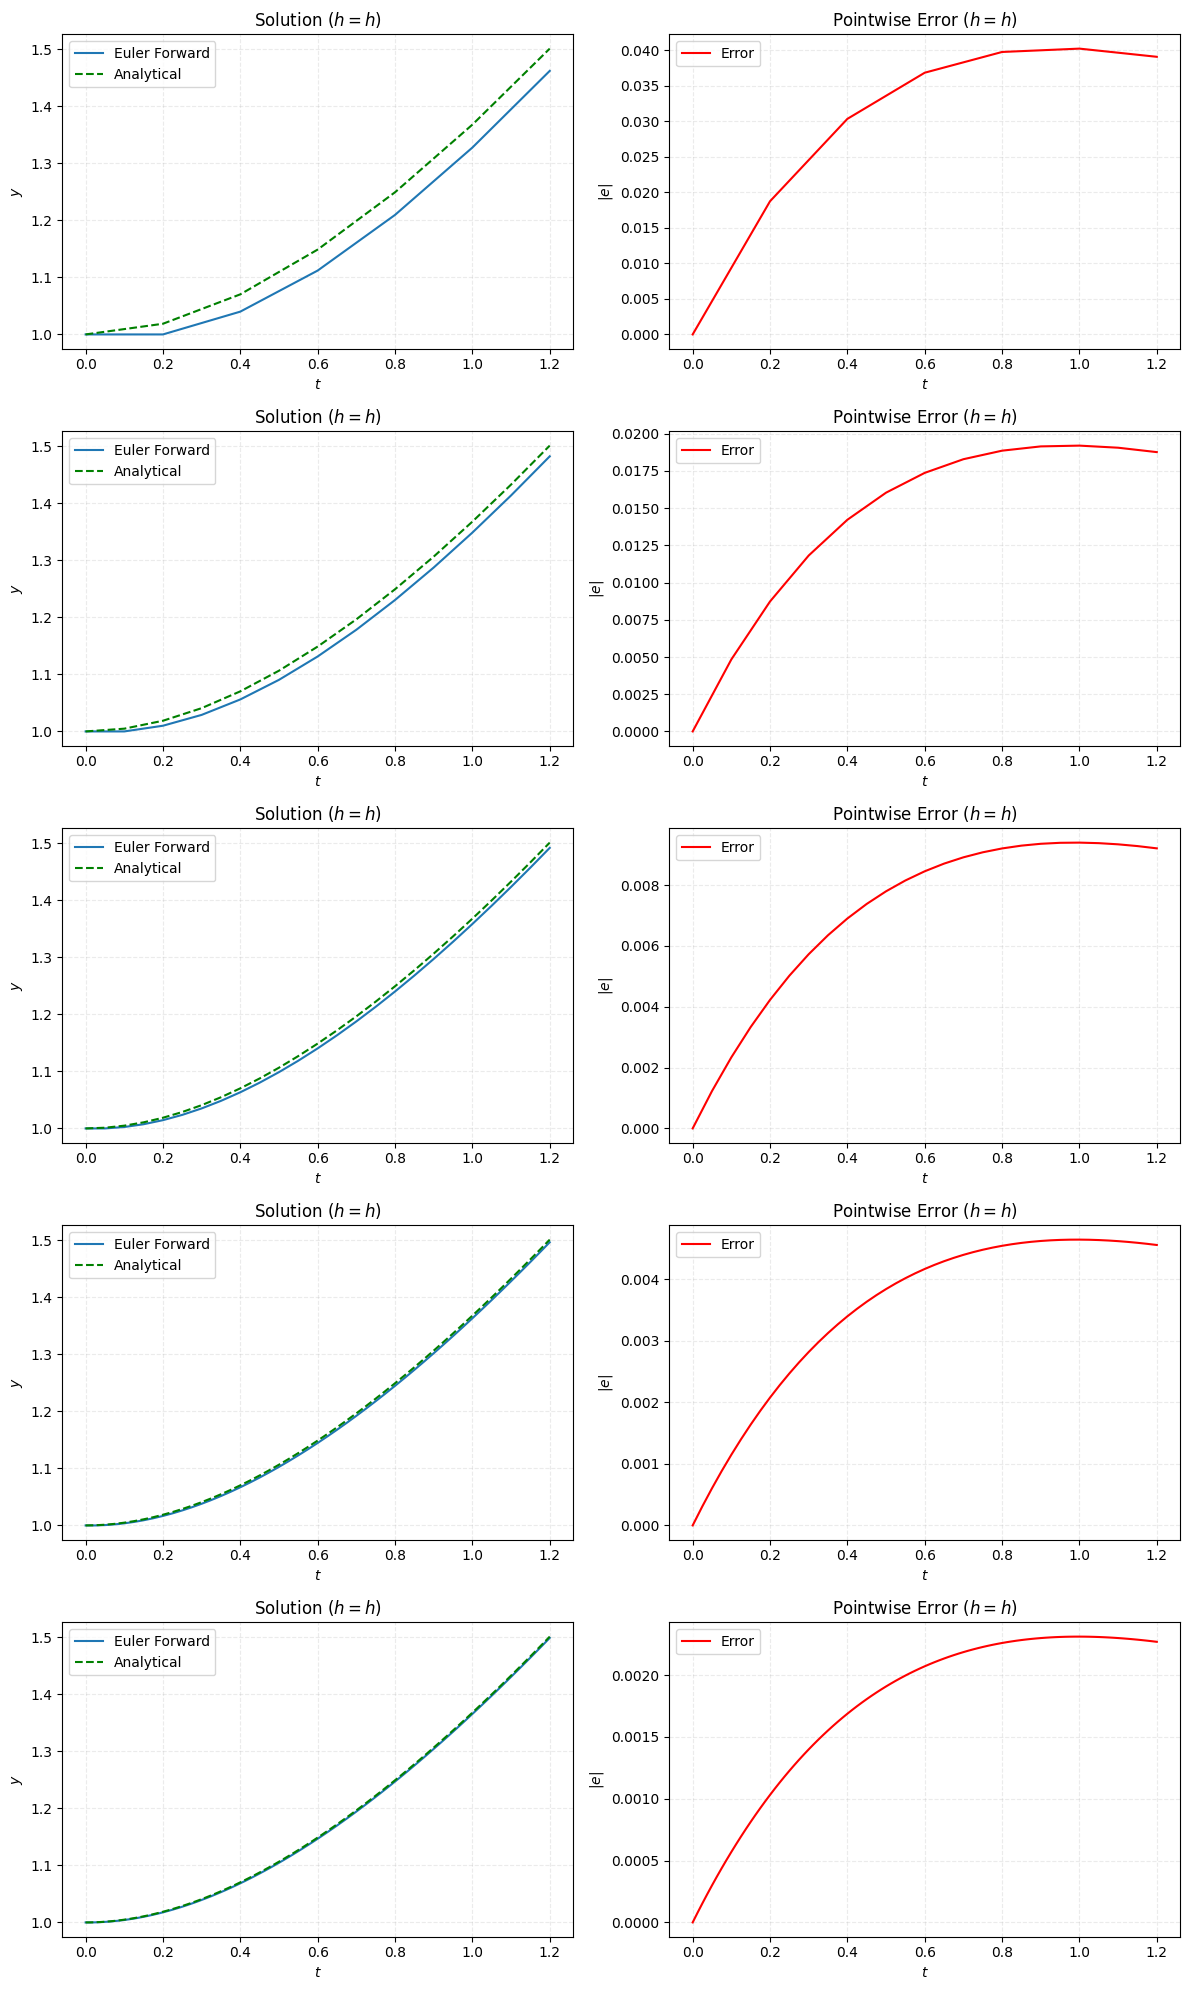

ANSWER B)
h          Max Error            Final Error         
--------------------------------------------------
0.2        0.040199             0.039050            
0.1        0.019201             0.018765            
0.05       0.009394             0.009205            
0.025      0.004647             0.004560            
0.0125     0.002311             0.002269            


In [69]:
# Convergence study
convergence_results = []

h_values = [0.2, 0.1, 0.05, 0.025, 0.0125]


for h in h_values:
    convergence_results.append(
        euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)
    )

fig, axes = plt.subplots(len(h_values), 2, figsize=(12, 4 * len(h_values)))

for i, (h, result) in enumerate(zip(h_values, convergence_results)):
    # Solution plots
    axes[i, 0].plot(result.t, result.y, label="Euler Forward")
    axes[i, 0].plot(
        result.t, result.y_exact, color="green", linestyle="dashed", label="Analytical"
    )
    axes[i, 0].set_title(r"Solution $(h={h})$")
    axes[i, 0].set_xlabel(r"$t$")
    axes[i, 0].set_ylabel(r"$y$")
    axes[i, 0].grid(True, alpha=0.25, linestyle="dashed")
    axes[i, 0].legend()

    # Error plots
    axes[i, 1].plot(result.t, result.e_i, color="red", label="Error")
    axes[i, 1].set_title(r"Pointwise Error $(h={h})$")
    axes[i, 1].set_xlabel(r"$t$")
    axes[i, 1].set_ylabel(r"$|e|$")
    axes[i, 1].grid(True, alpha=0.25, linestyle="dashed")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

print("ANSWER B)")
print(f"{'h':<10} {'Max Error':<20} {'Final Error':<20}")
print("-" * 50)
for h, result in zip(h_values, convergence_results):
    print(f"{h:<10} {max(result.e_i):<20.6f} {result.e_i[-1]:<20.6f}")


$e_{h/2} \approx C \cdot \left(\frac{h}{2}\right)^p$ so halving h tells us that the error is shrinking with a factor $1/2^p$

## F2.c)
Beräkna noggrannhetsordningen empiriskt genom formeln nedan och verifiera att de fyra
beräknade nogrannhetsordningarna blir p ≈ [1.057, 1.028, 1.013, 1.007].
$$p \approx \log\left(\frac{e_{k,h}}{e_{k,h/2}}\right) \cdot \frac{1}{\log(2)}$$
Since we will be halving $h$ we can rewrite this as: 
$$\log_2\left(\frac{e_{k,h}}{e_{k,h/2}}\right)$$

In [70]:
# order of convergence
convergence_results = []
h_values = [0.2, 0.1, 0.05, 0.025, 0.0125]


for h in h_values:
    convergence_results.append(
        euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)
    )

convergences = []
for i in range(len(convergence_results) - 1):
    e_h = convergence_results[i].e_i[-1]
    e_h2 = convergence_results[i + 1].e_i[-1]
    p = np.log2(e_h / e_h2)
    convergences.append(p)

for i, p in enumerate(convergences):
    print(f"h={h_values[i]:.4f} -> h/2={h_values[i + 1]:.4f} : p={p:.3f}")


h=0.2000 -> h/2=0.1000 : p=1.057
h=0.1000 -> h/2=0.0500 : p=1.028
h=0.0500 -> h/2=0.0250 : p=1.013
h=0.0250 -> h/2=0.0125 : p=1.007


$e \approx C \cdot h^p$ so halving h tells us that the error is shrinking with a factor $2^p$

___
# T1) Elektriskt system - högre ordningens differentialekvation.

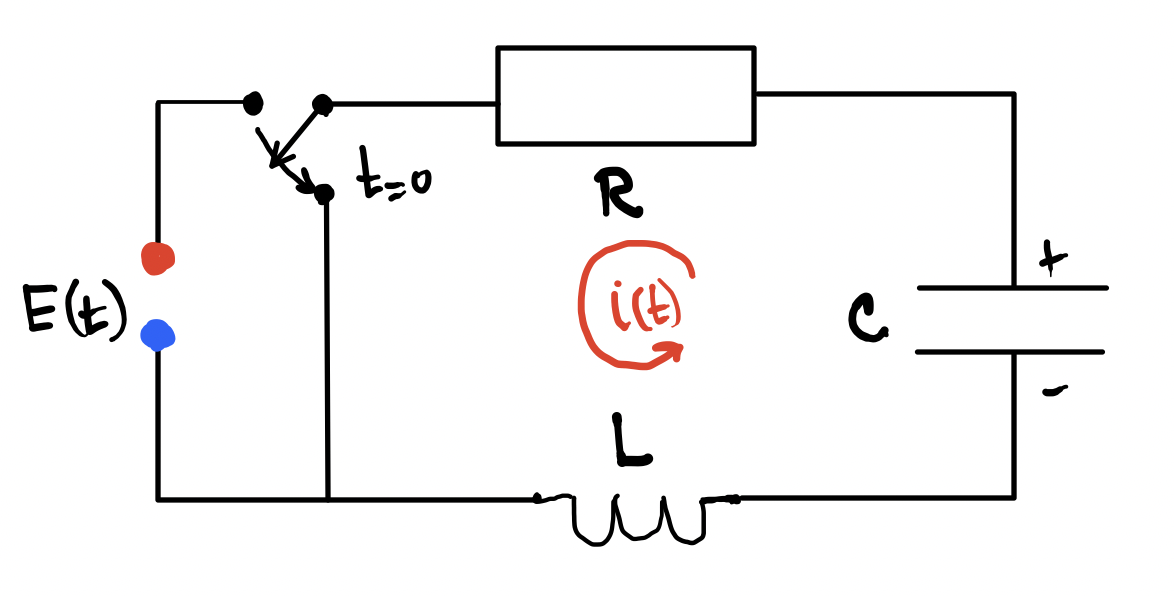

### T1.a)

Skriv om ekvation (2) till ett system av första ordningens differentialekvationer med hjälp
av ekvation (3).

DE for the charge $q(t)$ is:

$$\text{DE2:}\quad L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac{1}{C}q = 0$$

Introduce the substitution $i = \frac{dq}{dt}$ and rearrange:

$$\text{DE2*:} \quad \frac{di}{dt} = -\frac{R}{L}i - \frac{1}{LC}q$$

Rewrite in vectorform $\frac{d}{dt}\vec{y} = \vec{F}(t, \vec{y})$ where $\vec{y} = \begin{pmatrix} q \\ i \end{pmatrix}$:

$$\frac{d}{dt}\vec{y} = \frac{d}{dt} \begin{pmatrix} q \\ i \end{pmatrix} = \begin{pmatrix} \dot{q} \\ \ddot{q} \end{pmatrix} = \vec{F}(t, \vec{y}) = \begin{pmatrix} i \\ -\dfrac{R}{L}i - \dfrac{1}{LC}q \end{pmatrix}$$

Note that the initial charge at $t=0$ for the condensator was $Q_0$, we therefore get: 
$$\text{IC:} \quad y(0) = \begin{pmatrix} Q_0 \\ 0 \end{pmatrix}$$



### T1.b

Skriv en Python-funktion som tar tiden t, en vektor y, och värden på R, L, C som inpa-
rametrar. Funktionen ska returnera vektorn F(t, y). Funktionen ska vara skriven så att den
går att använda med Pythons inbyggda ode-lösare solve_ivp

In [71]:
# ODE function for T1.b
def ODET1a(t: list[float], y: np.ndarray, R: float, L: float, C: float) -> np.ndarray:
    """
    Returns the ODE in vector form from task T1.a

    Parameters
    ------
    t : float
        time

    y : np.ndarray
        2D vector containing first and second derivative of q

    R : float
        Circuit Resistance (Ohm)

    L : float
        Circuit Inductance (Henry)

    C : float
        Circuit Capacitance (Farad)

    Returns
    -------


    """
    q, i = y
    dq = i
    di = -(R / L) * i - (1 / (L * C)) * q
    return np.array([dq, di])


## T1.c)

Lös systemet av differentialekvationer från a) med Pythons inbyggda funktion solve_ivp
och metoden RK45 på tidsintervallet t = [0, 20] med

$$ i) \quad Q0 = 1, L = 2, C = 0.5, R = 1, \text{dampened}$$

$$ii) \quad Q0 = 1, L = 2, C = 0.5, R = 0, \text{undampened}$$

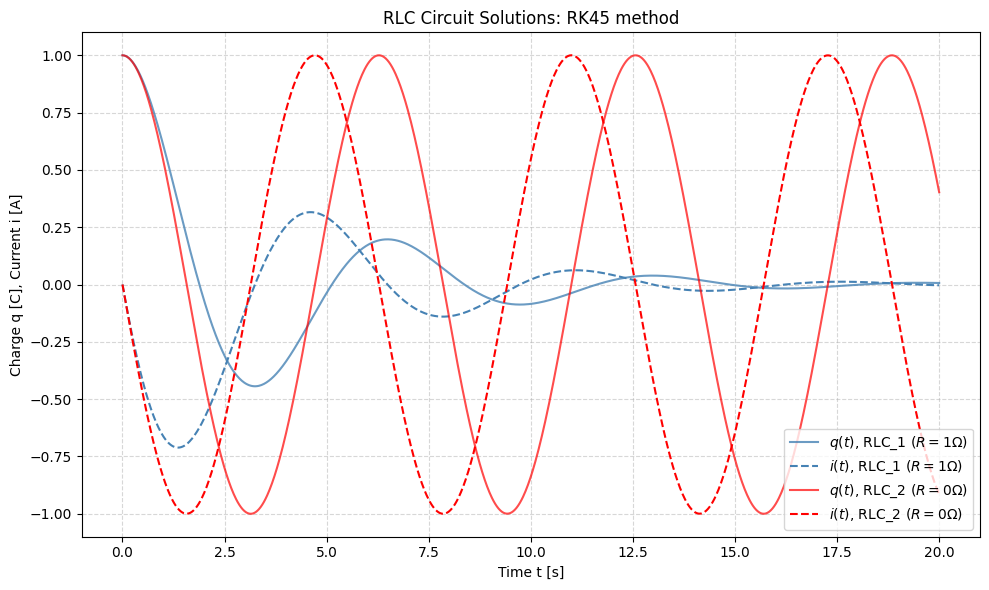

In [72]:
# Solving damped / undampened system of eq using solve_ivp
@dataclass
class RLC:
    Q_0: float
    L: float
    C: float
    R: float


RLC_1: RLC = RLC(1, 2, 0.5, 1)
RLC_2: RLC = RLC(1, 2, 0.5, 0)

METHOD: str = "RK45"
t_span: tuple = (0, 20)
STEPS: int = 1000

sol1 = solve_ivp(
    ODET1a,
    t_span,
    [RLC_1.Q_0, 0],
    args=(RLC_1.R, RLC_1.L, RLC_1.C),
    method=METHOD,
    t_eval=np.linspace(0, 20, STEPS),
)

sol2 = solve_ivp(
    ODET1a,
    t_span,
    [RLC_2.Q_0, 0],
    args=(RLC_2.R, RLC_2.L, RLC_2.C),
    method=METHOD,
    t_eval=np.linspace(0, 20, STEPS),
)


plt.figure(figsize=(10, 6))

# RLC_1
plt.plot(
    sol1.t,
    sol1.y[0],
    color="steelblue",
    label=r"$q(t)$, RLC_1 $(R=1Ω)$",
    linewidth=1.5,
    alpha=0.8,
)
plt.plot(
    sol1.t,
    sol1.y[1],
    color="steelblue",
    linestyle="dashed",
    label=r"$i(t)$, RLC_1 $(R=1 \Omega)$",
)

# RLC_2
plt.plot(
    sol2.t,
    sol2.y[0],
    color="red",
    label=r"$q(t)$, RLC_2 $(R=0 \Omega)$",
    linewidth=1.5,
    alpha=0.7,
)
plt.plot(
    sol2.t,
    sol2.y[1],
    color="red",
    linestyle="dashed",
    label=r"$i(t)$, RLC_2 ($R=0 \Omega$)",
)

plt.xlabel("Time t [s]")
plt.ylabel("Charge q [C], Current i [A]")
plt.title("RLC Circuit Solutions: RK45 method")
plt.legend()
plt.grid(True, alpha=0.5, linestyle="dashed")
plt.tight_layout()
plt.show()


We can clearly see that the undampened solution oscillates forever while the dampened decays, which is what we expected.

## T1.d)
Dela nu in tidsintervallet t = [0, 20] i N = 20, 40, 80, 160 ekvidistanta tidssteg. För varje
värde på N , lös systemet av differentialekvationer från a) med Euler framåt. Använd L =
2, C = 0.5, R = 1 (dämpad svängning). Plotta lösningen för varje värde på N .
För vilka värden på N blir den numeriska lösningen stabil (dvs lösningen växer ej)? För vilka
värden på N blir den numeriska lösningen instabil? Notera att en numerisk lösning kan vara
stabil men ändå inte noggrann (använd lösningen från solve_ivp som referenslösning, dvs
för att approximera den exakta lösningen).



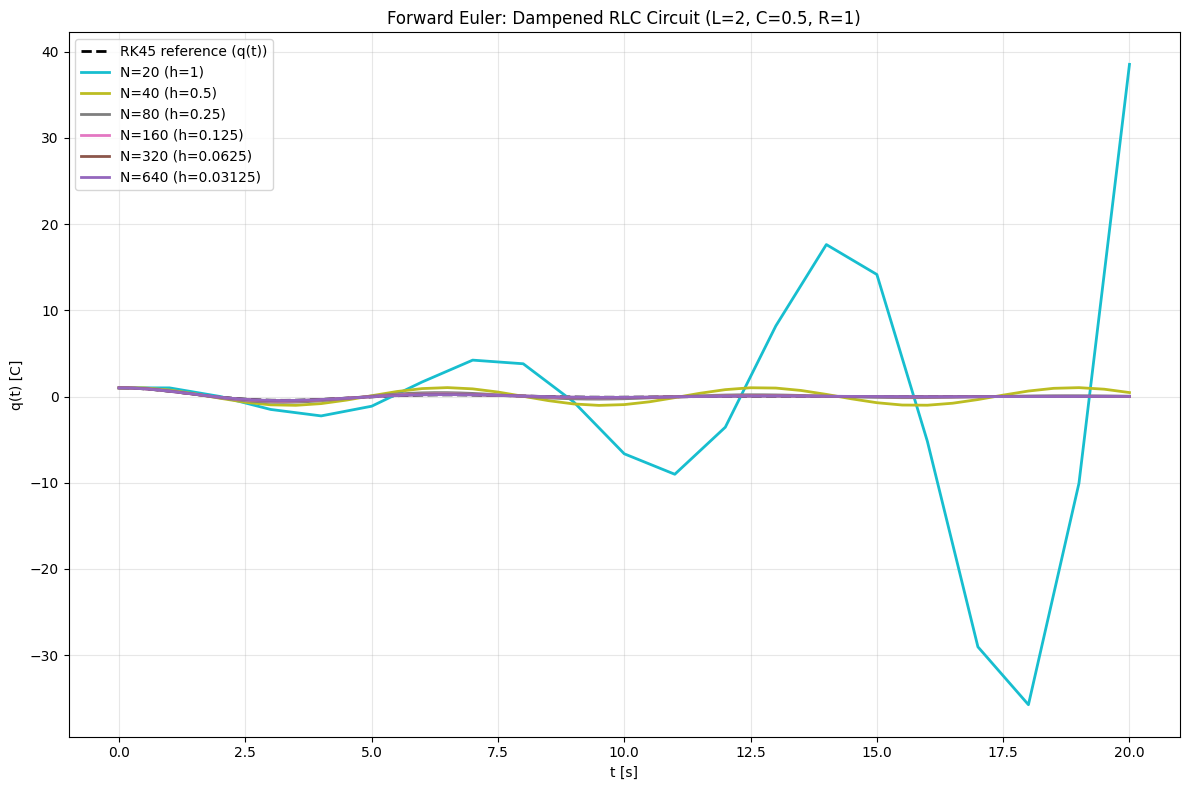

In [73]:
# Testing stability on t:0->20
t_span = [0, 20]
N_start = 20
N_levels = 6
N = [N_start * 2**i for i in range(N_levels)]
RLC_1 = RLC(Q_0=1, L=2, C=0.5, R=1)
sols = []

for n_steps in N:
    h = t_span[1] / n_steps  # Equidistant: stepsize = T/N
    y0 = np.array([RLC_1.Q_0, 0.0])
    sol = euler_forward(ODET1a, y0, t_span, h, RLC_1.R, RLC_1.L, RLC_1.C)
    sols.append(sol)

# print(sols[0])

plt.figure(figsize=(12, 8))

# Reference RK45 solution
plt.plot(sol1.t, sol1.y[0], "k--", linewidth=2, label="RK45 reference (q(t))")

cmap = plt.cm.tab10_r  # type: ignore
for i, sol in enumerate(sols):
    label = f"N={N[i]} (h={t_span[1] / N[i]:.4g})"
    plt.plot(sol.t, sol.y[:, 0], color=cmap(i), linestyle="-", linewidth=2, label=label)

plt.xlabel("t [s]")
plt.ylabel("q(t) [C]")
plt.title("Forward Euler: Dampened RLC Circuit (L=2, C=0.5, R=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


***Answer***: On $t \isin [0, 20]$ all but $N=20$ are stable.

## T1.e)

För fallet med dämpad svängning, utför en konvergensstudie för Euler framåt och bestäm
noggrannhetsordningen för metoden empiriskt. 

Beräkna felet komponentvis, se förklaring
nedan, vid sluttiden T = 20 och använd lösningen från solve_ivp som referenslösning. 

Gör så här: 

Börja med ett värde på N som leder till en stabil numerisk lösning.

Dubblera sedan N (halvera tidssteget h) successivt och beräkna felen (ett fel per komponent i lösningen) för
varje värde på N.

Följ stegen i F2 c) för att beräkna noggrannhetsordningen komponentvis.

In [74]:
# Conv. Study for T1.e
y_ref_end = sol1.y[:, -1]  # [q_ref(20), i_ref(20)]

N_start = 40
N_levels = 5
N_values = [N_start * 2**i for i in range(N_levels)]

t_span: list = [0, 20]

errors_q, errors_i = [], []

print(f"{'-' * 65}")
for N in N_values:
    h = t_span[-1] / N
    y0 = np.array([RLC_1.Q_0, 0.0])
    sol = euler_forward(ODET1a, y0, t_span, h, RLC_1.R, RLC_1.L, RLC_1.C)
    y_end = sol.y[:, -1]
    # calc. abs(Euler - solve_ivp)
    err_q = abs(y_end[0] - y_ref_end[0])
    err_i = abs(y_end[1] - y_ref_end[1])
    errors_q.append(err_q)
    errors_i.append(err_i)
    print(f"N: {N:<6}| Stepsize: {h:<8.4f}| e_q: {err_q:<12.2e}| e_i: {err_i:<12.2e}")

print("\nOrder p:")
print(f"{'-' * 65}")
for k in range(1, len(N_values)):
    p_q = np.log2(errors_q[k - 1] / errors_q[k])
    p_i = np.log2(errors_i[k - 1] / errors_i[k])
    print(
        f"N: {N_values[k - 1]:>3} - {N_values[k]:<3} --> p_q={p_q:.3f}, p_i={p_i:.4f}"
    )


-----------------------------------------------------------------
N: 40    | Stepsize: 0.5000  | e_q: 6.68e-03    | e_i: 4.97e-01    
N: 80    | Stepsize: 0.2500  | e_q: 6.68e-03    | e_i: 2.47e-01    
N: 160   | Stepsize: 0.1250  | e_q: 6.68e-03    | e_i: 1.22e-01    
N: 320   | Stepsize: 0.0625  | e_q: 6.68e-03    | e_i: 5.91e-02    
N: 640   | Stepsize: 0.0312  | e_q: 6.68e-03    | e_i: 2.78e-02    

Order p:
-----------------------------------------------------------------
N:  40 - 80  --> p_q=0.000, p_i=1.0099
N:  80 - 160 --> p_q=0.000, p_i=1.0200
N: 160 - 320 --> p_q=0.000, p_i=1.0409
N: 320 - 640 --> p_q=0.000, p_i=1.0856


The table above shows that the absolute error for q between Euler method and RK45 is virtually indistinguishable while the e_i has a negative trend with the decreasing stepsize.

$e_{h/2} \approx C \cdot \left(\frac{h}{2}\right)^p$ so halving h tells us that the error is shrinking with a factor $1/2^p$

# T2) Termiskt system. Temperatur i stav - randvärdesproblem.


Temperaturfördelningen i en cylindrisk stav med längden L beskrivs av differentialekvationen

$$

k \frac{d²T}{dx²} = q(x), \quad 0 < x < L, \\

T(0) = T_L, \\

T(L) = T_R

$$

$$
q_{analytical}(x) = 50 x³ \ln{(x+1)}, \quad h = \frac{L}{N}, \quad x_i = hi, \quad i=0,1,...,N, \quad T_L = T_R = k = 2, \quad L = 1
$$

## T2.a)
Diskretisera (4) med centrala finita differenser för N = 4. Skriv ut systemmatrisen och
högerledet med alla element.

Finite difference formula for second derivative: 

$$
T_{xx,i} \approx \frac{1}{h²} \left( T_{i + 1} - 2T_i + T_{i - 1}\right), \\
$$
So in our case: 
$$
q(x_i) = T_{xx,i} \approx \frac{k}{h²} \left( T_{i + 1} - 2T_i + T_{i - 1}\right), \\
$$

We use $N=4$ intervals and note that $T_0 = T_L$, $T_4 = T_R$ are know from the BC's, we get:

$$
q(x_1) = \frac{k}{h^2}(T_2 - 2T_1 + T_0) \implies \frac{k}{h^2}(-2T_1 + T_2) = q(x_1) - \frac{k}{h^2}T_0 \\
q(x_2) = \frac{k}{h^2}(T_3 - 2T_2 + T_1)  \implies \frac{k}{h^2}(T_1 - 2T_2 + T_3) = q(x_2)\\
q(x_3) = \frac{k}{h^2}(T_4 - 2T_3 + T_2)  \implies \frac{k}{h^2}(T_2 - 2T_3) = q(x_3) - \frac{k}{h^2}T_4
$$
And so we get the system:

$$
\frac{k}{h^2} \begin{pmatrix} -2 & 1 & 0 \\ 1 & -2 & 1 \\ 0 & 1 & -2 \end{pmatrix} \begin{pmatrix} T_1 \\ T_2 \\ T_3 \end{pmatrix} = \begin{pmatrix} q(x_1) - \frac{k}{h^2}T_L \\ q(x_2) \\ q(x_3) - \frac{k}{h^2}T_R \end{pmatrix}

$$


## T2.b)
By noting that whatever number of intervals $N$ we choose, the finite difference formula will take the same form as above with the initial and final value being known for the first and last equation. So, when we generalize the above system we get a tridiagonal $(N-1)\times(N-1)$ matrix with 1s on the sub- and superdiagonals and -2 on the main diagonal with $\mathbf{T}$ being of length $(N-1)$, giving the system $\mathbf{A}\mathbf{T} = \mathbf{b}$:

$$
\mathbf{A} = \frac{k}{h^2}\begin{pmatrix} 
-2 & 1 & 0 & \cdots & 0 \\ 
1 & -2 & 1 & \cdots & 0 \\ 
0 & 1 & -2 & \cdots & 0 \\ 
\vdots & & \ddots & \ddots & \vdots \\ 
0 & \cdots & 0 & 1 & -2 
\end{pmatrix}
$$

$$
\mathbf{T} = \begin{pmatrix} T_1 \\ T_2 \\ \vdots \\ T_{N-1} \end{pmatrix}, \qquad
\mathbf{b} = \begin{pmatrix} q(x_1) - \frac{k}{h^2}T_L \\ q(x_2) \\ \vdots \\ q(x_{N-2}) \\ q(x_{N-1}) - \frac{k}{h^2}T_R \end{pmatrix}
$$

## T2.c)

In [75]:
# diskretisering_temperatur func.


def diskretisering_temperatur(
    N: int, q: Callable, k: float, L: float | None, T_0: float, T_L: float # type:ignore
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculates and returns the system matrix for a static heat conduction problem on a 1-dim rod of lenght L:

    T(x), 0 < x < L
    kT_xx = q(x), 0 < x < L

    T(0) = T_0,
    T(L) = T_L,

    by solving the system AT = b using the finite difference method:

    T_xx,i = (1/h²)(T_(i+1) - 2T_i + T_(i-1))

    Parameters
    -------
    N : int
        Number of intervals
    q(x) : Callable
        Callable 1-dim source function
    k : float
        Heat conduction coefficient
    L : float or None
        Length of rod (0 < x < L)
    T_L : float
        BC at x = 0
    T_R : float
        BC at x = L

    Returns
    -------
    A : np.ndarray
        (N-1)x(N-1) tridiagonal system matrix
    b : np.ndarray
        Right-hand side vector of length (N-1), including boundary conditions

    """

    L: float = L if L is not None else 1.0
    A_size: int = N - 1
    h: float = L / N  # stepsize
    x: np.ndarray = np.linspace(
        h, L - h, N - 1
    )  # discretionalize the rod but exclude BC's

    # Build A
    A = (k / h**2) * (-2 * np.eye(A_size) + np.eye(A_size, k=1) + np.eye(A_size, k=-1))

    # calc b
    b = np.zeros(A_size)
    for idx, xi in enumerate(x):
        b[idx] = q(xi)
    b[0] -= (k / h**2) * T_0
    b[-1] -= (k / h**2) * T_L

    return A, b


N = 4
L = 1
k = 2
T_0 = 2
T_L = 2


def q(x: float) -> Callable:
    """Source func. for static 1-dim heat problem"""
    return 50 * x**3 * np.log(x + 1)


A, HL = diskretisering_temperatur(N, q, k, L, T_0, T_L)
print(f"A = \n {A} \n")
print(f"b = {HL}")


A = 
 [[-64.  32.   0.]
 [ 32. -64.  32.]
 [  0.  32. -64.]] 

b = [-63.8256691    2.53415693 -52.19560447]


Output of **diskretisering_temperatur** ok..

## T2.d)
Lös randvärdesproblemet med N = 100 och plotta temperaturen som funktion av x.

Vad blir den approximativa temperaturen vid x = 0.2?

A = 
 [2.         1.99369116 1.98738232 1.98107349 1.97476465 1.96845582
 1.96214701 1.95583823 1.9495295  1.94322087 1.93691241 1.93060417
 1.92429629 1.9179889  1.91168218 1.90537635 1.89907171 1.89276858
 1.88646739 1.8801686  1.8738728  1.86758065 1.86129291 1.85501046
 1.84873431 1.8424656  1.8362056  1.82995575 1.82371767 1.81749313
 1.81128412 1.80509283 1.79892164 1.79277319 1.78665037 1.7805563
 1.7744944  1.76846837 1.7624822  1.75654022 1.75064707 1.74480775
 1.73902764 1.73331248 1.7276684  1.72210199 1.71662022 1.71123054
 1.70594086 1.70075957 1.69569556 1.69075827 1.68595764 1.6813042
 1.67680904 1.67248386 1.66834096 1.66439329 1.66065447 1.65713877
 1.65386117 1.65083738 1.64808382 1.6456177  1.64345701 1.64162052
 1.64012784 1.63899943 1.63825662 1.63792162 1.63801756 1.63856852
 1.63959952 1.64113658 1.64320671 1.64583795 1.64905942 1.65290128
 1.65739482 1.66257245 1.66846771 1.67511533 1.68255126 1.69081263
 1.69993785 1.7099666  1.72093985 1.7328999  1.74589041 1.

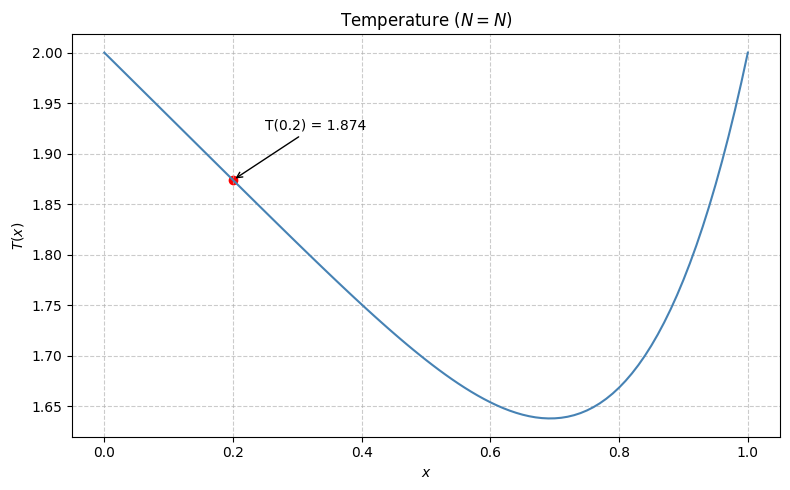

In [76]:
# N = 100
# vars
N = 100
L = 1
k = 2
T_0 = 2
T_L = 2


def q(x: float) -> Callable:
    """Source func. for static 1-dim heat problem"""
    return 50 * x**3 * np.log(x + 1)


A, b = diskretisering_temperatur(N, q, k, L, T_0, T_L)

# Solve system and append the boundarie values at x = 0 and x = L
T = np.linalg.solve(A, b)
x_0 = np.linspace(1 / N, L - 1 / N, N - 1)
x_L = np.concatenate([[0], x_0, [L]])
T = np.concatenate([[T_0], T, [T_L]])

h = L / N
x_find = 0.2
T_find = np.argmin(np.abs(x_L - x_find))


# print(f'Size of A = {np.size(T)} \n')
print(f"A = \n {T} \n")
print(f"Temp of T({x_find}) = {T[T_find]:1.3f}")

plt.figure(figsize=(8, 5))
plt.plot(x_L, T, color="steelblue")
plt.xlabel(r"$x$")
plt.ylabel(r"$T(x)$")
plt.title(r"Temperature $(N={N})$")
plt.grid(True, linestyle="dashed", alpha=0.65)
plt.tight_layout()
plt.annotate(
    f"T({x_find}) = {T[T_find]:1.3f}",
    xy=(x_find, T[T_find]),
    xytext=(x_find + 0.05, T[T_find] + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
)
plt.scatter(x_find, T[T_find], color="red")
plt.show()


Since $q(x) = 50x³\ln{(x + 1)} > 0, \forall x: x > 0$ the second derivative $T_{xx,i}$ will always be positive, thus q(x) is acting like a heat sink.This, coupled with the fact that $T_{xx} = \frac{q(x)}{k} > 0 \quad \forall x \isin (0, L]$ means that the resulting solution must have a minimum somewhere in the interior which matches the results well.

## T2.e) Convergence Study

In [77]:
# Conv. Study T2 - temperature at x = 0.7
# Parameters
x_target = 0.7
T_ref = 1.6379544
L, k_cond, T_0, T_L = 1, 2, 2, 2
N_start = 10
N_levels = 10
N_values = [N_start * 2**i for i in range(N_levels)]


def get_T_at(n, x):
    """Solve system and return temperature at a given x."""
    h = L / n
    A, b = diskretisering_temperatur(n, q, k_cond, L, T_0, T_L)
    T_sol = np.linalg.solve(A, b)
    # index: 0, 1,..., N-2
    #     x: h, 2h, ..., (N-1)h
    index = round(x / h) - 1
    return float(T_sol[index])


errors = [abs(get_T_at(n, x_target) - T_ref) for n in N_values]
T_vals = [get_T_at(n, x_target) for n in N_values]


print(f"{'-' * 60}")
print(f"{'N':<8}{'h':<12}{'T(0.7)':<16}{'error':<12}")
print(f"{'-' * 60}")
for n, T_val, err in zip(N_values, T_vals, errors):
    print(f"{n:<8}{L / n:<12.5f}{T_val:<16.7f}{err:<12.2e}")

print(f"{'-' * 60}")
print(f"{'ref':<8}{'':12}{T_ref:<16.7f}{'-':<12}")
print(f"{'-' * 60}")

print(f"\nOrder p:\n{'-' * 60}")
for j in range(1, len(N_values)):
    p = np.log2(errors[j - 1] / errors[j])
    print(f"N: {N_values[j - 1]:>4} -> {N_values[j]:<4} | p = {p:.3f}")


------------------------------------------------------------
N       h           T(0.7)          error       
------------------------------------------------------------
10      0.10000     1.6442606       6.31e-03    
20      0.05000     1.6395329       1.58e-03    
40      0.02500     1.6383491       3.95e-04    
80      0.01250     1.6380531       9.87e-05    
160     0.00625     1.6379791       2.47e-05    
320     0.00313     1.6379606       6.17e-06    
640     0.00156     1.6379559       1.54e-06    
1280    0.00078     1.6379548       3.83e-07    
2560    0.00039     1.6379545       9.43e-08    
5120    0.00020     1.6379544       2.20e-08    
------------------------------------------------------------
ref                 1.6379544       -           
------------------------------------------------------------

Order p:
------------------------------------------------------------
N:   10 -> 20   | p = 1.998
N:   20 -> 40   | p = 2.000
N:   40 -> 80   | p = 2.000
N:   80 -> 16

## T2.f)


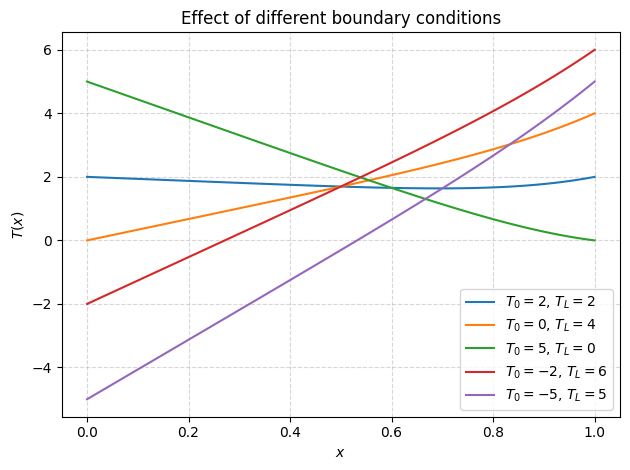

In [78]:
# BC study
for T_0, T_L in [(2, 2), (0, 4), (5, 0), (-2, 6), (-5, 5)]:
    A, b = diskretisering_temperatur(100, q, 2, 1, T_0, T_L)
    T_sol = np.linalg.solve(A, b)
    x_full = np.linspace(0, 1, 101)
    T_full = np.concatenate([[T_0], T_sol, [T_L]])
    plt.plot(x_full, T_full, label=rf"$T_0={T_0}$, $T_L={T_L}$")

plt.title("Effect of different boundary conditions")
plt.xlabel(r"$x$")
plt.ylabel(r"$T(x)$")
plt.legend()
plt.grid(True, alpha=0.5, linestyle="dashed")
plt.tight_layout()
plt.show()
